In [ ]:
# 初始化词表：特殊 token + 256 个字节
SPECIAL_TOKEN = "<|endoftext|>"

# 0–255 每个整数对应一个单独字节（bytes 对象）
byte_tokens = [bytes([i]) for i in range(256)]

# 词表顺序：先特殊 token，再 256 个字节 token
vocab = [SPECIAL_TOKEN.encode('utf-8')] + byte_tokens

# 若需要映射到 id，可直接枚举
token_to_id = {tok: idx for idx, tok in enumerate(vocab)}

from collections import Counter
corpus = [
    "low low low low low",
    "lower lower widest widest widest",
    "newest newest newest newest newest newest",
]
word_freq = Counter(word for line in corpus for word in line.split())

def word_to_byte_tuple(word):
    return tuple(bytes([b]) for b in word.encode('utf-8'))

byte_tuple_freq = {word_to_byte_tuple(word) : c for word, c in word_freq.items()}

from collections import defaultdict
def pair_stats(tok_dict):
    stats = defaultdict(int)
    for seq, freq in tok_dict.items():
        for i in range(len(seq) - 1):
            stats[(seq[i], seq[i+1])] += freq
    return stats
def merge_once(tok_dict, pair):
    a, b = pair
    merge = a + b
    new_dict = {}
    for seq, freq in tok_dict.items():
        new_seq, i = [], 0
        while i < len(seq):
            if i < len(seq) - 1 and seq[i] == a and seq[i+1] == b:
                new_seq.append(merge)
                i += 2
            else:
                new_seq.append(seq[i])
                i += 1
        new_dict[tuple(new_seq)] = freq
    return new_dict
tokens = byte_tuple_freq
for _ in range(6):
    stats = pair_stats(tokens)
    top_freq = max(stats.values())
    best = max(p for p, c in stats.items() if c == top_freq)
    tokens = merge_once(tokens, best)
    new_token = best[0] + best[1]
    if new_token not in tokens:
        token_id = len(vocab)
        vocab.append(new_token)
        token_to_id[new_token] = token_id

In [ ]:
import json

# Read the JSON file
with open("../tokenizer_vocab_owt_32k.json", "r", encoding="utf-8") as f:
    token_dict = json.load(f)

word_dict = {k: bytes.fromhex(v).decode("utf-8", errors="replace") for k, v in token_dict.items()}
# Find the longest token (by character length)
longest_token = max(word_dict.values(), key=len)
print(f"Longest token: {repr(longest_token)}")
print(f"Length: {len(longest_token)}")

In [ ]:
import json
import binascii

# 模拟 BPE 的数据结构
id_to_token = {
    0: b"a",
    1: b"b",
    2: b"\xff\x00",         # 非 ASCII 字节
}

merged = [
    (b"a", b"b"),
    (b"\xff", b"\x00"),
]

# 写入 vocab（JSON）
with open("tokenizer_vocab.json", "w", encoding="utf-8") as f:
    json.dump({
        str(k): binascii.hexlify(v).decode("ascii")
        for k, v in id_to_token.items()
    }, f, indent=2)

# 读取 vocab
with open("tokenizer_vocab.json", encoding="utf-8") as f:
    vocab_raw = json.load(f)
    id_to_token_loaded = {
        int(k): binascii.unhexlify(v)
        for k, v in vocab_raw.items()
    }

# 写入 merges（TSV）
with open("tokenizer_merges.tsv", "w", encoding="utf-8") as f:
    for a, b in merged:
        f.write(f"{a.hex()}\t{b.hex()}\n")

# 读取 merges
with open("tokenizer_merges.tsv", encoding="utf-8") as f:
    merged_loaded = [
        (bytes.fromhex(a), bytes.fromhex(b))
        for line in f
        for a, b in [line.strip().split("\t")]
    ]

# ✅ 验证是否完全一致
assert id_to_token == id_to_token_loaded, "❌ id_to_token 不一致"
assert merged == merged_loaded, "❌ merged 不一致"

print("✅ vocab 和 merges 成功写入、读取、还原一致！")


In [21]:
SEP_RE = re.compile("|".join(map(re.escape, [])))


In [ ]:
SEP_RE.split("hello world")

In [ ]:
import time

# 模拟 32000 条 merge 规则
merge_rules = [((bytes([i % 256]), bytes([(i + 1) % 256]))) for i in range(32000)]
merge_ranks = {pair: i for i, pair in enumerate(merge_rules)}

# 模拟一个 UTF-8 编码的 token 列表（比如来自 "apple"）
tokens = [b"a", b"p", b"p", b"l", b"e"]

# 方法一：while + sort heap 模拟（查所有 pair 并找最优）
def encode_method_1(tokens, merge_ranks):
    tokens = tokens[:]
    while True:
        pairs = [(tokens[i], tokens[i + 1]) for i in range(len(tokens) - 1)]
        ranked = [(pair, merge_ranks[pair]) for pair in pairs if pair in merge_ranks]
        if not ranked:
            break
        ranked.sort(key=lambda x: x[1])
        best = ranked[0][0]

        i = 0
        while i < len(tokens) - 1:
            if (tokens[i], tokens[i + 1]) == best:
                tokens[i:i + 2] = [tokens[i] + tokens[i + 1]]
                break
            i += 1
    return tokens

# 方法二：for rank in merges 顺序遍历（标准 encode 方法）
def encode_method_2(tokens, merges):
    tokens = tokens[:]
    for a, b in merges:
        i = 0
        while i < len(tokens) - 1:
            if tokens[i] == a and tokens[i + 1] == b:
                tokens[i:i + 2] = [a + b]
                if i > 0:
                    i -= 1
            else:
                i += 1
    return tokens

# 运行时间比较
repeats = 1000
start = time.time()
for _ in range(repeats):
    encode_method_1(tokens, merge_ranks)
time_method_1 = time.time() - start

start = time.time()
for _ in range(repeats):
    encode_method_2(tokens, merge_rules)
time_method_2 = time.time() - start

time_method_1, time_method_2

encode_method_1(tokens, merge_ranks) == encode_method_2(tokens, merge_ranks)

In [ ]:
import regex as re

class DummyTokenizer:
    def __init__(self):
        # 简化的合并规则：bigrams -> rank
        self.merge_ranks = {
            (b'h', b'e'): 1,
            (b'e', b'l'): 2,
            (b'l', b'l'): 3,
            (b'l', b'o'): 4,
            (b'w', b'o'): 5,
            (b'o', b'r'): 6,
            (b'r', b'l'): 7,
            (b'l', b'd'): 8,
        }

        # 简单的 token 到 id 映射
        self.token_to_id = {}
        vocab = [b'h', b'e', b'l', b'o', b'w', b'r', b'd', b'he', b'el', b'll', b'lo', b'wo', b'or', b'rl', b'ld',
                 b'<|endoftext|>']
        for i, t in enumerate(vocab):
            self.token_to_id[t if isinstance(t, bytes) else t.encode("utf-8")] = i

        self.special_tokens = ['<|endoftext|>']

    def encode(self, text: str) -> list[int]:
        print(self.token_to_id)
        PAT = re.compile(
            r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""",
            flags=re.VERSION1
        )

        if self.special_tokens:
            SEP_RE = re.compile("|".join(map(re.escape, self.special_tokens)))
            segments = SEP_RE.split(text)
            matches = list(SEP_RE.finditer(text))
        else:
            segments = [text]
            matches = []

        result = []
        seg_idx = 0
        match_idx = 0

        while seg_idx < len(segments) or match_idx < len(matches):
            if seg_idx < len(segments):
                segment = segments[seg_idx]
                if segment:
                    for word in PAT.finditer(segment):
                        bytes_word = word.group().encode("utf-8")
                        tokens = [bytes_word[i:i + 1] for i in range(len(bytes_word))]
                        while True:
                            pairs = [(tokens[i], tokens[i + 1]) for i in range(len(tokens) - 1)]
                            ranked = [(pair, self.merge_ranks[pair]) for pair in pairs if pair in self.merge_ranks]
                            if not ranked:
                                break
                            best_pair = min(ranked, key=lambda x: x[1])[0]
                            i = 0
                            while i < len(tokens) - 1:
                                if (tokens[i], tokens[i + 1]) == best_pair:
                                    tokens[i:i + 2] = [tokens[i] + tokens[i + 1]]
                                    break
                                i += 1
                        for tok in tokens:
                            result.append(self.token_to_id[tok])
                seg_idx += 1
            if match_idx < len(matches):
                special_token = matches[match_idx].group().encode("utf-8")
                result.append(self.token_to_id[special_token])
                match_idx += 1
        return result


# 🧪 示例调用
tokenizer = DummyTokenizer()
ids = tokenizer.encode("<|endoftext|>hello<|endoftext|>world")
print(ids)


In [ ]:
from typing import Iterator
def segment_and_match_iter(text: str, sep_re: re.Pattern) -> Iterator[tuple[str, str]]:
    last_end = 0
    for match in sep_re.finditer(text):
        start, end = match.span()
        yield text[last_end:start], match.group()
        last_end = end
    yield text[last_end:], None  # 最后一个 segment 没有 match 跟随
text = "hello<|endoftext|><|endoftext|>world<|endoftext|>"
special_tokens = ['<|endoftext|>']
sep_re = re.compile("|".join(map(re.escape, special_tokens)))

for segment, match in segment_and_match_iter(text, sep_re):
    print("segment:", segment, "match:", match)

In [ ]:
from Tokenizer import Tokenizer

tokenizer = Tokenizer.from_files("../tokenizer_vocab_tinystories_10k.json", "../tokenizer_merges_tinystories_10k.txt")

ids = tokenizer.encode("hello<|endoftext|><|endoftext|>world<|endoftext|>")
print(ids)

text = tokenizer.decode(ids)
print(text)

In [ ]:
import random

random.seed(42)  # 固定随机种子，确保每次结果一样

with open("../data/owt_valid.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

documents = raw_text.split("<|endoftext|>")
documents = [doc.strip() for doc in documents if doc.strip()]

sampled = random.sample(documents, 10)

for i, doc in enumerate(sampled, 1):
    print(f"\n--- Document {i} ---\n{doc[:500]}...\n")

In [13]:
import random
import json
from Tokenizer import Tokenizer

# 设置随机种子确保结果可重现
random.seed(42)

def load_documents(file_path, delimiter="<|endoftext|>"):
    """从文件中加载文档"""
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
    
    # 按分隔符分割文档
    documents = content.split(delimiter)
    # 过滤空文档并去掉首尾空白
    documents = [doc.strip() for doc in documents if doc.strip()]
    return documents

def sample_documents(documents, n=10):
    """从文档列表中随机采样n个文档"""
    return random.sample(documents, min(n, len(documents)))

def calculate_compression_ratio(tokenizer, text):
    """计算压缩比 (bytes/token)"""
    # 编码为token IDs
    token_ids = tokenizer.encode(text)
    
    # 计算原始字节数
    byte_count = len(text.encode('utf-8'))
    
    # 计算token数量
    token_count = len(token_ids)
    
    # 计算压缩比
    compression_ratio = byte_count / token_count if token_count > 0 else 0
    
    return compression_ratio, byte_count, token_count

# 加载文档
print("加载TinyStories文档...")
tinystories_docs = load_documents("../data/TinyStoriesV2-GPT4-valid.txt")
print(f"TinyStories总文档数: {len(tinystories_docs)}")

print("加载OpenWebText文档...")
owt_docs = load_documents("../data/owt_valid.txt")
print(f"OpenWebText总文档数: {len(owt_docs)}")

# 采样文档
print("\\n采样10个文档...")
sample_tinystories = sample_documents(tinystories_docs, 10)
sample_owt = sample_documents(owt_docs, 10)

print(f"TinyStories采样文档数: {len(sample_tinystories)}")
print(f"OpenWebText采样文档数: {len(sample_owt)}")


加载TinyStories文档...
TinyStories总文档数: 27630
加载OpenWebText文档...
OpenWebText总文档数: 59059
\n采样10个文档...
TinyStories采样文档数: 10
OpenWebText采样文档数: 10


In [14]:
# 加载预训练的tokenizer
print("加载tokenizer...")
tinystories_tokenizer = Tokenizer.from_files(
    "../tokenizer_vocab_tinystories_10k.json", 
    "../tokenizer_merges_tinystories_10k.txt",
    special_tokens=["<|endoftext|>"]
)
print(f"TinyStories tokenizer词汇量: {len(tinystories_tokenizer.id_to_token)}")

owt_tokenizer = Tokenizer.from_files(
    "../tokenizer_vocab_owt_32k.json", 
    "../tokenizer_merges_owt_32k.txt",
    special_tokens=["<|endoftext|>"]
)
print(f"OpenWebText tokenizer词汇量: {len(owt_tokenizer.id_to_token)}")

# 计算TinyStories tokenizer在TinyStories数据上的压缩比
print("\\n=== TinyStories Tokenizer在TinyStories数据上的表现 ===")
ts_total_bytes = 0
ts_total_tokens = 0
ts_ratios = []

for i, doc in enumerate(sample_tinystories):
    ratio, bytes_count, token_count = calculate_compression_ratio(tinystories_tokenizer, doc)
    ts_total_bytes += bytes_count
    ts_total_tokens += token_count
    ts_ratios.append(ratio)
    print(f"文档 {i+1}: {ratio:.3f} bytes/token ({bytes_count} bytes, {token_count} tokens)")

ts_avg_ratio = ts_total_bytes / ts_total_tokens
print(f"\\nTinyStories tokenizer在TinyStories数据上的平均压缩比: {ts_avg_ratio:.3f} bytes/token")
print(f"总计: {ts_total_bytes} bytes, {ts_total_tokens} tokens")


加载tokenizer...
TinyStories tokenizer词汇量: 10000
OpenWebText tokenizer词汇量: 32000
\n=== TinyStories Tokenizer在TinyStories数据上的表现 ===
文档 1: 4.018 bytes/token (687 bytes, 171 tokens)
文档 2: 3.991 bytes/token (2666 bytes, 668 tokens)
文档 3: 4.074 bytes/token (603 bytes, 148 tokens)
文档 4: 4.436 bytes/token (448 bytes, 101 tokens)
文档 5: 4.046 bytes/token (797 bytes, 197 tokens)
文档 6: 4.414 bytes/token (565 bytes, 128 tokens)
文档 7: 4.104 bytes/token (710 bytes, 173 tokens)
文档 8: 3.876 bytes/token (814 bytes, 210 tokens)
文档 9: 3.987 bytes/token (630 bytes, 158 tokens)
文档 10: 4.131 bytes/token (537 bytes, 130 tokens)
\nTinyStories tokenizer在TinyStories数据上的平均压缩比: 4.058 bytes/token
总计: 8457 bytes, 2084 tokens


In [15]:
# 计算OpenWebText tokenizer在OpenWebText数据上的压缩比
print("=== OpenWebText Tokenizer在OpenWebText数据上的表现 ===")
owt_total_bytes = 0
owt_total_tokens = 0
owt_ratios = []

for i, doc in enumerate(sample_owt):
    ratio, bytes_count, token_count = calculate_compression_ratio(owt_tokenizer, doc)
    owt_total_bytes += bytes_count
    owt_total_tokens += token_count
    owt_ratios.append(ratio)
    print(f"文档 {i+1}: {ratio:.3f} bytes/token ({bytes_count} bytes, {token_count} tokens)")

owt_avg_ratio = owt_total_bytes / owt_total_tokens
print(f"\\nOpenWebText tokenizer在OpenWebText数据上的平均压缩比: {owt_avg_ratio:.3f} bytes/token")
print(f"总计: {owt_total_bytes} bytes, {owt_total_tokens} tokens")


=== OpenWebText Tokenizer在OpenWebText数据上的表现 ===
文档 1: 4.898 bytes/token (3110 bytes, 635 tokens)
文档 2: 4.657 bytes/token (16296 bytes, 3499 tokens)
文档 3: 4.752 bytes/token (1473 bytes, 310 tokens)
文档 4: 4.897 bytes/token (5774 bytes, 1179 tokens)
文档 5: 4.860 bytes/token (7994 bytes, 1645 tokens)
文档 6: 4.916 bytes/token (6287 bytes, 1279 tokens)
文档 7: 4.061 bytes/token (9449 bytes, 2327 tokens)
文档 8: 4.332 bytes/token (8157 bytes, 1883 tokens)
文档 9: 4.862 bytes/token (8047 bytes, 1655 tokens)
文档 10: 4.445 bytes/token (9987 bytes, 2247 tokens)
\nOpenWebText tokenizer在OpenWebText数据上的平均压缩比: 4.597 bytes/token
总计: 76574 bytes, 16659 tokens


In [16]:
# 交叉验证：TinyStories tokenizer在OpenWebText数据上的表现
print("=== 交叉验证：TinyStories Tokenizer在OpenWebText数据上的表现 ===")
ts_owt_total_bytes = 0
ts_owt_total_tokens = 0

for i, doc in enumerate(sample_owt):
    ratio, bytes_count, token_count = calculate_compression_ratio(tinystories_tokenizer, doc)
    ts_owt_total_bytes += bytes_count
    ts_owt_total_tokens += token_count
    print(f"文档 {i+1}: {ratio:.3f} bytes/token ({bytes_count} bytes, {token_count} tokens)")

ts_owt_avg_ratio = ts_owt_total_bytes / ts_owt_total_tokens
print(f"\\nTinyStories tokenizer在OpenWebText数据上的平均压缩比: {ts_owt_avg_ratio:.3f} bytes/token")

# 交叉验证：OpenWebText tokenizer在TinyStories数据上的表现
print("\\n=== 交叉验证：OpenWebText Tokenizer在TinyStories数据上的表现 ===")
owt_ts_total_bytes = 0
owt_ts_total_tokens = 0

for i, doc in enumerate(sample_tinystories):
    ratio, bytes_count, token_count = calculate_compression_ratio(owt_tokenizer, doc)
    owt_ts_total_bytes += bytes_count
    owt_ts_total_tokens += token_count
    print(f"文档 {i+1}: {ratio:.3f} bytes/token ({bytes_count} bytes, {token_count} tokens)")

owt_ts_avg_ratio = owt_ts_total_bytes / owt_ts_total_tokens
print(f"\\nOpenWebText tokenizer在TinyStories数据上的平均压缩比: {owt_ts_avg_ratio:.3f} bytes/token")


=== 交叉验证：TinyStories Tokenizer在OpenWebText数据上的表现 ===
文档 1: 3.132 bytes/token (3110 bytes, 993 tokens)
文档 2: 2.917 bytes/token (16296 bytes, 5587 tokens)
文档 3: 3.402 bytes/token (1473 bytes, 433 tokens)
文档 4: 3.210 bytes/token (5774 bytes, 1799 tokens)
文档 5: 3.109 bytes/token (7994 bytes, 2571 tokens)
文档 6: 3.487 bytes/token (6287 bytes, 1803 tokens)
文档 7: 3.461 bytes/token (9449 bytes, 2730 tokens)
文档 8: 2.684 bytes/token (8157 bytes, 3039 tokens)
文档 9: 3.592 bytes/token (8047 bytes, 2240 tokens)
文档 10: 3.563 bytes/token (9987 bytes, 2803 tokens)
\nTinyStories tokenizer在OpenWebText数据上的平均压缩比: 3.191 bytes/token
\n=== 交叉验证：OpenWebText Tokenizer在TinyStories数据上的表现 ===
文档 1: 3.796 bytes/token (687 bytes, 181 tokens)
文档 2: 3.892 bytes/token (2666 bytes, 685 tokens)
文档 3: 4.047 bytes/token (603 bytes, 149 tokens)
文档 4: 4.308 bytes/token (448 bytes, 104 tokens)
文档 5: 4.005 bytes/token (797 bytes, 199 tokens)
文档 6: 4.380 bytes/token (565 bytes, 129 tokens)
文档 7: 4.034 bytes/token (710 bytes, 176

\n============================================================
                         Compression Ratio Summary
TinyStories tokenizer (10K vocab):
  On TinyStories data: 4.058 bytes/token
  On OpenWebText data: 3.191 bytes/token

OpenWebText tokenizer (32K vocab):
  On OpenWebText data: 4.597 bytes/token
  On TinyStories data: 3.943 bytes/token

Analysis:
1. TinyStories tokenizer performs better on its training data (4.058 vs 3.191)
2. OpenWebText tokenizer performs better on its training data (4.597 vs 3.943)
3. The larger vocabulary OpenWebText tokenizer has lower overall compression ratio


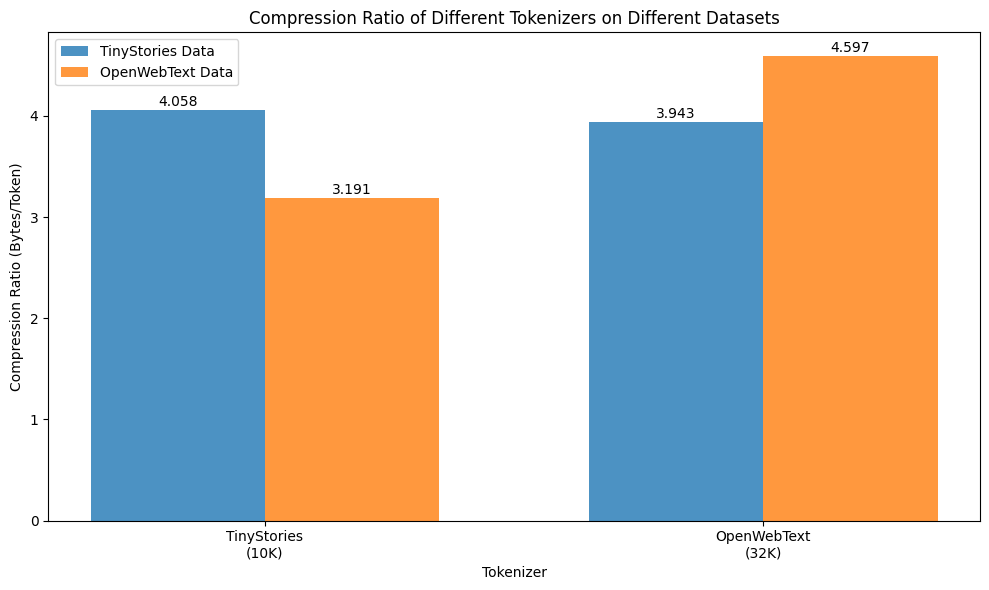

In [21]:
# Summary of results
print("\\n" + "="*60)
print("                         Compression Ratio Summary")
print("="*60)
print(f"TinyStories tokenizer (10K vocab):")
print(f"  On TinyStories data: {ts_avg_ratio:.3f} bytes/token")
print(f"  On OpenWebText data: {ts_owt_avg_ratio:.3f} bytes/token")
print()
print(f"OpenWebText tokenizer (32K vocab):")
print(f"  On OpenWebText data: {owt_avg_ratio:.3f} bytes/token") 
print(f"  On TinyStories data: {owt_ts_avg_ratio:.3f} bytes/token")
print()
print("Analysis:")
print(f"1. TinyStories tokenizer performs better on its training data ({ts_avg_ratio:.3f} vs {ts_owt_avg_ratio:.3f})")
print(f"2. OpenWebText tokenizer performs better on its training data ({owt_avg_ratio:.3f} vs {owt_ts_avg_ratio:.3f})")
print(f"3. The larger vocabulary OpenWebText tokenizer has lower overall compression ratio")

# Visualization results
import matplotlib.pyplot as plt
import numpy as np

tokenizers = ['TinyStories\n(10K)', 'OpenWebText\n(32K)']
ts_data = [ts_avg_ratio, owt_ts_avg_ratio]
owt_data = [ts_owt_avg_ratio, owt_avg_ratio]

x = np.arange(len(tokenizers))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, ts_data, width, label='TinyStories Data', alpha=0.8)
bars2 = ax.bar(x + width/2, owt_data, width, label='OpenWebText Data', alpha=0.8)

ax.set_xlabel('Tokenizer')
ax.set_ylabel('Compression Ratio (Bytes/Token)')
ax.set_title('Compression Ratio of Different Tokenizers on Different Datasets')
ax.set_xticks(x)
ax.set_xticklabels(tokenizers)
ax.legend()

# Add value labels
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')

add_value_labels(bars1)
add_value_labels(bars2)

plt.tight_layout()
plt.show()
